# Regression Model Development Guide (Simplified)

A step-by-step template for building and comparing regression models:
- **Linear Regression** (Baseline)
- **Random Forest**
- **LightGBM**
- **XGBoost**
- **CatBoost**

---

## Step 1: Identify the Target Variable (y)

Define the variable you want to predict (the dependent variable).

In [9]:
# ========== MODIFY THIS ==========
TARGET_COLUMN = 'resale_price'  # Target column for HDB resale price prediction
# =================================

---

## Step 2: Import Packages and Load Dataset

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

# Import regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

# Configure plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.style.use('fivethirtyeight')

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("All packages imported successfully!")

All packages imported successfully!


In [3]:
# ========== MODIFY THIS ==========
# Load your dataset
DATA_PATH = 'Consolidated Flat Transactions.csv'
# =================================

df = pd.read_csv(DATA_PATH)

# Preview the data
print(f"Dataset loaded with shape: {df.shape}")
df.head()

Dataset loaded with shape: (270619, 76)


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,61,0,1.369092,103.839041,474.789674,Ang Mo Kio Secondary School,224,0,1.367359,103.842600
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,61,0,1.369092,103.839041,522.935557,Mayflower Secondary School,219,0,1.368337,103.835439
2,2012-03,ANG MO KIO,4 ROOM,105,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,430000.0,...,61,0,1.369092,103.839041,398.421190,CHIJ Saint Nicholas Girls' School,256,1,1.373730,103.834309
3,2012-03,ANG MO KIO,4 ROOM,108,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,427000.0,...,61,0,1.369092,103.839041,424.046635,Mayflower Secondary School,219,0,1.368337,103.835439
4,2012-03,ANG MO KIO,3 ROOM,110,ANG MO KIO AVE 4,01 TO 05,67.0,New Generation,1978,323000.0,...,61,0,1.369092,103.839041,322.732547,Mayflower Secondary School,219,0,1.368337,103.835439


---

## Step 3: Explore the Dataset Structure

Check the number of features, data types, and basic statistics.

In [5]:
# Check dimensions (rows, columns)
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print("\n" + "="*50)

# View column names and data types
print("\nColumn Info:")
print(df.info())

Dataset shape: (270619, 76)
Number of features: 76


Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270619 entries, 0 to 270618
Data columns (total 76 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Tranc_YearMonth            270619 non-null  object 
 1   town                       270619 non-null  object 
 2   flat_type                  270619 non-null  object 
 3   block                      270619 non-null  object 
 4   street_name                270619 non-null  object 
 5   storey_range               270619 non-null  object 
 6   floor_area_sqm             270619 non-null  float64
 7   flat_model                 270619 non-null  object 
 8   lease_commence_date        270619 non-null  int64  
 9   resale_price               270619 non-null  float64
 10  Tranc_Year                 270619 non-null  int64  
 11  Tranc_Month                270619 non-null  int64  
 12  mid_storey          

In [6]:
# View basic statistics for numeric columns
df.describe()

,floor_area_sqm,lease_commence_date,resale_price,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,floor_area_sqft,...,pri_sch_nearest_distance,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
count,270619.000000,270619.000000,2.706190e+05,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,...,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000
mean,96.688538,1994.860209,5.077318e+05,2019.382867,6.569993,8.540509,7.520218,9.560800,8.540509,1040.751170,...,410.333804,49.501099,0.110421,1.367462,103.839956,524.446040,119.498162,0.036088,1.367066,103.840203
std,24.158391,13.743470,1.758274e+05,3.938842,3.322633,5.753127,5.757832,5.751876,5.753127,260.039993,...,246.979262,20.722907,0.313414,0.042797,0.071881,315.536641,97.268801,0.186509,0.042629,0.071779
min,31.000000,1966.000000,1.500000e+05,2012.000000,1.000000,2.000000,1.000000,3.000000,2.000000,333.680900,...,42.554863,0.000000,0.000000,1.274962,103.687589,38.913475,5.000000,0.000000,1.276029,103.687207
25%,76.000000,1984.000000,3.800000e+05,2016.000000,4.000000,5.000000,4.000000,6.000000,5.000000,818.056400,...,232.375000,32.000000,0.000000,1.337408,103.776108,297.943031,19.000000,0.000000,1.338179,103.777148
50%,93.000000,1995.000000,4.730000e+05,2020.000000,7.000000,8.000000,7.000000,9.000000,8.000000,1001.052000,...,361.106748,48.000000,0.000000,1.365518,103.844934,459.407453,188.000000,0.000000,1.367107,103.844934
75%,112.000000,2004.000000,6.038880e+05,2023.000000,9.000000,11.000000,10.000000,12.000000,11.000000,1205.556800,...,524.571779,64.000000,0.000000,1.394958,103.898773,669.551509,211.000000,0.000000,1.396218,103.899872
max,366.700000,2022.000000,1.658888e+06,2025.000000,12.000000,50.000000,49.000000,51.000000,50.000000,3947.122130,...,3306.003143,138.000000,1.000000,1.456667,103.962919,3638.977233,260.000000,1.000000,1.453280,103.961105


In [7]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing Values:")
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values:
                       Missing Count  Missing %
Mall_Nearest_Distance           5210       1.93
Mall_Within_500m              168137      62.13
Mall_Within_1km                49132      18.16
Mall_Within_2km                 7036       2.60
Hawker_Within_500m            177013      65.41
Hawker_Within_1km             109046      40.30
Hawker_Within_2km              52516      19.41


---

## Step 3.5: Feature Engineering (Optional)

Create new features by combining or transforming existing columns. This can help capture relationships that improve model performance.

**Common feature engineering techniques:**
- **Ratio features**: e.g., `floor_ratio = mid_storey / max_floor_lvl` (relative floor position)
- **Interaction features**: e.g., `area_x_storey = floor_area_sqm * mid_storey`
- **Binning**: e.g., categorizing `hdb_age` into groups
- **Log transformations**: e.g., `log_price = log(resale_price)`

> **Warning:** Avoid features derived from the target variable (e.g., `price_per_sqm = resale_price / floor_area_sqm`) as this creates **data leakage**. See `Price_Per_Sqm_Analysis.ipynb` for details.

In [8]:
# ========== FEATURE ENGINEERING SECTION ==========
# Add new engineered features below. Each feature is created from existing columns.

# Example 1: Relative floor position (0-1 scale, where 1 = top floor)
# Captures floor premium without being perfectly correlated with mid_storey or max_floor_lvl
df['floor_ratio'] = df['mid_storey'] / df['max_floor_lvl']

# Example 2: Uncomment and modify these or add your own
# df['area_x_storey'] = df['floor_area_sqm'] * df['mid_storey']
# df['distance_score'] = df['mrt_nearest_distance'] + df['Mall_Nearest_Distance']
# df['remaining_lease'] = 99 - df['hdb_age']  # Note: highly correlated with hdb_age

# ========== ADD YOUR CUSTOM FEATURES BELOW ==========
# 
# Template: df['new_feature_name'] = <formula using existing columns>
# 
# Example ideas:
# - df['total_distance'] = df['mrt_nearest_distance'] + df['Mall_Nearest_Distance'] + df['Hawker_Nearest_Distance']
# - df['is_high_floor'] = (df['mid_storey'] > 10).astype(int)
# - df['age_squared'] = df['hdb_age'] ** 2
# 
# ⚠️ AVOID: Features derived from target (e.g., price_per_sqm = resale_price / floor_area_sqm)
#    This creates DATA LEAKAGE. See Price_Per_Sqm_Analysis.ipynb for details.
# 
# =================================================

# Display the newly created columns
new_columns = ['floor_ratio']  # Add names of your new features to this list
print("Engineered Features Created:")
for col in new_columns:
    if col in df.columns:
        print(f"  - {col}: min={df[col].min():.2f}, max={df[col].max():.2f}, mean={df[col].mean():.2f}")

print(f"\nDataset now has {df.shape[1]} columns")
df.head()

Engineered Features Created:
  - floor_ratio: min=0.04, max=1.50, mean=0.56

Dataset now has 77 columns


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude,floor_ratio
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,0,1.369092,103.839041,474.789674,Ang Mo Kio Secondary School,224,0,1.367359,103.842600,0.666667
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,0,1.369092,103.839041,522.935557,Mayflower Secondary School,219,0,1.368337,103.835439,0.666667
2,2012-03,ANG MO KIO,4 ROOM,105,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,430000.0,...,0,1.369092,103.839041,398.421190,CHIJ Saint Nicholas Girls' School,256,1,1.373730,103.834309,0.800000
3,2012-03,ANG MO KIO,4 ROOM,108,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,427000.0,...,0,1.369092,103.839041,424.046635,Mayflower Secondary School,219,0,1.368337,103.835439,0.666667
4,2012-03,ANG MO KIO,3 ROOM,110,ANG MO KIO AVE 4,01 TO 05,67.0,New Generation,1978,323000.0,...,0,1.369092,103.839041,322.732547,Mayflower Secondary School,219,0,1.368337,103.835439,0.250000


---

## Step 4: Select Features for Modeling

Choose relevant features based on domain knowledge and exploratory analysis.

In [4]:
# ========== MODIFY THIS ==========
# Define feature columns (numeric and categorical)

# Numeric features that likely influence resale price
NUMERIC_FEATURES = [
    'floor_area_sqm',
    'lease_commence_date',
    'Tranc_Month',
    'Mall_Nearest_Distance',
    'Mall_Within_2km',
    'Hawker_Nearest_Distance',
    'hawker_food_stalls',
    'hawker_market_stalls',
    'mrt_nearest_distance',
    'pri_sch_nearest_distance',
    'Tranc_Year',
    'mid_storey',
    'max_floor_lvl',
    'Latitude',
    'Longitude',
    'vacancy',
    'pri_sch_affiliation',
    'sec_sch_nearest_dist',
]

# Engineered features (created in Step 3.5)
ENGINEERED_FEATURES = []

# Categorical features
CATEGORICAL_FEATURES = [
    'flat_type',
    'planning_area',
    'mrt_name',
    'town',
]

# All features combined (numeric + engineered + categorical)
ALL_FEATURES = NUMERIC_FEATURES + ENGINEERED_FEATURES + CATEGORICAL_FEATURES
# =================================

print(f"Numeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"\nEngineered features ({len(ENGINEERED_FEATURES)}): {ENGINEERED_FEATURES}")
print(f"\nCategorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"\nTotal features: {len(ALL_FEATURES)}")

Numeric features (18): ['floor_area_sqm', 'lease_commence_date', 'Tranc_Month', 'Mall_Nearest_Distance', 'Mall_Within_2km', 'Hawker_Nearest_Distance', 'hawker_food_stalls', 'hawker_market_stalls', 'mrt_nearest_distance', 'pri_sch_nearest_distance', 'Tranc_Year', 'mid_storey', 'max_floor_lvl', 'Latitude', 'Longitude', 'vacancy', 'pri_sch_affiliation', 'sec_sch_nearest_dist']

Engineered features (0): []

Categorical features (4): ['flat_type', 'planning_area', 'mrt_name', 'town']

Total features: 22


---

## Step 5: Analyze Feature Correlations

Visualize correlations between numeric features (including engineered features) and the target variable.

In [10]:
# Correlation matrix for numeric features + engineered features + target
corr_cols = NUMERIC_FEATURES + ENGINEERED_FEATURES + [TARGET_COLUMN]
correlation_matrix = df[corr_cols].corr()

# Show correlations with target variable, sorted by strength
print("Correlations with Target Variable:")
print(correlation_matrix[TARGET_COLUMN].sort_values(ascending=False))

Correlations with Target Variable:
resale_price                1.000000
floor_area_sqm              0.584071
max_floor_lvl               0.474855
lease_commence_date         0.400101
mid_storey                  0.345751
Tranc_Year                  0.338276
sec_sch_nearest_dist        0.101502
Mall_Within_2km             0.097314
Longitude                   0.095732
pri_sch_nearest_distance    0.021869
pri_sch_affiliation         0.018503
Tranc_Month                -0.009765
Hawker_Nearest_Distance    -0.013050
hawker_food_stalls         -0.041886
Mall_Nearest_Distance      -0.066250
hawker_market_stalls       -0.087071
Latitude                   -0.155731
mrt_nearest_distance       -0.168964
vacancy                    -0.205150
Name: resale_price, dtype: float64


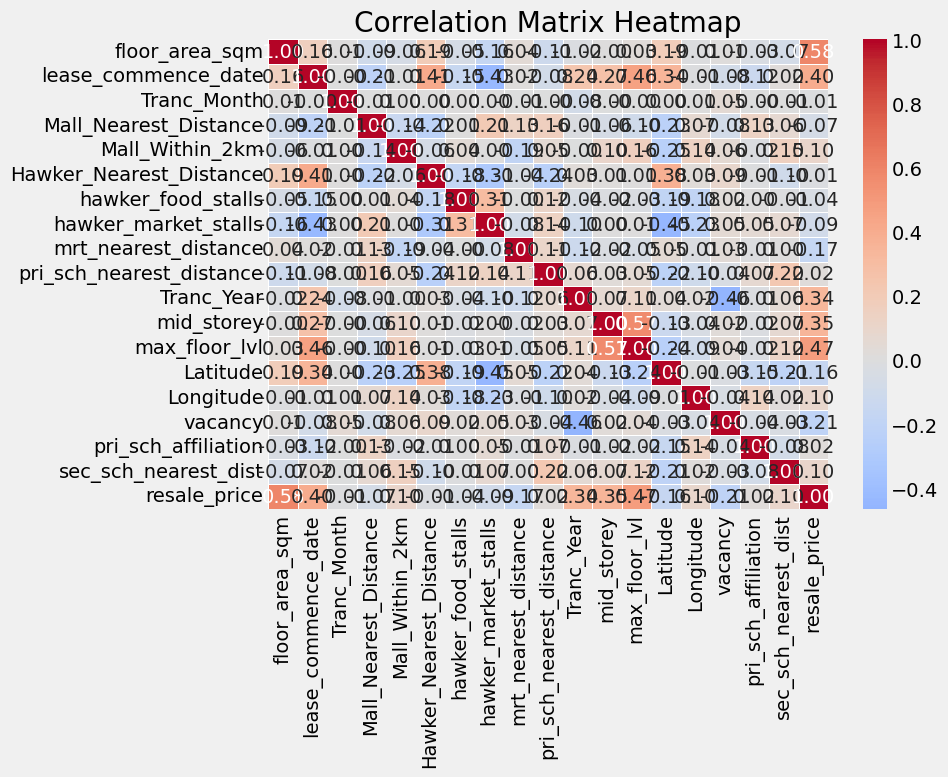

In [31]:
# Visualize correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, center=0)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

In [6]:
# Check for highly correlated features (multicollinearity)
# This helps identify features that may be redundant

CORRELATION_THRESHOLD = 0.7  # Features with correlation above this may cause issues

# Get correlation matrix without target
feature_corr = df[NUMERIC_FEATURES + ENGINEERED_FEATURES].corr()

# Find pairs of highly correlated features
high_corr_pairs = []
for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        corr_val = abs(feature_corr.iloc[i, j])
        if corr_val > CORRELATION_THRESHOLD:
            high_corr_pairs.append({
                'Feature 1': feature_corr.columns[i],
                'Feature 2': feature_corr.columns[j],
                'Correlation': feature_corr.iloc[i, j]
            })

if high_corr_pairs:
    print(f"⚠️ Highly Correlated Feature Pairs (|r| > {CORRELATION_THRESHOLD}):")
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(high_corr_df.to_string(index=False))
    print("\nConsider removing one feature from each pair to reduce multicollinearity.")
else:
    print(f"✓ No feature pairs have correlation above {CORRELATION_THRESHOLD}")

✓ No feature pairs have correlation above 0.7


---

## Step 6: Prepare Data for Modeling

Handle missing values and encode categorical variables.

Two encoding strategies are used:
- **Label Encoding** -> for tree models (Random Forest, LightGBM, XGBoost, CatBoost)
- **One-Hot Encoding** -> for Linear Regression (avoids fake numeric ordering of categories)

### 6a. Drop Missing Values

In [11]:
# Create a copy of the dataframe with selected features
model_df = df[ALL_FEATURES + [TARGET_COLUMN]].copy()

# Drop rows with missing values in selected columns
initial_rows = len(model_df)
model_df = model_df.dropna()
rows_dropped = initial_rows - len(model_df)
pct_dropped = rows_dropped / initial_rows * 100
print(f"Rows before cleaning: {initial_rows}")
print(f"Rows after cleaning:  {len(model_df)}")
print(f"Rows dropped:         {rows_dropped} ({pct_dropped:.1f}%)")

Rows before cleaning: 270619
Rows after cleaning:  263583
Rows dropped:         7036 (2.6%)


In [12]:
# ===== 6b. LABEL ENCODING — for tree models =====
# Tree-based models can handle integer-encoded categoricals efficiently

label_encoders = {}
model_df_encoded = model_df.copy()

if CATEGORICAL_FEATURES:
    for col in CATEGORICAL_FEATURES:
        le = LabelEncoder()
        model_df_encoded[col] = le.fit_transform(model_df_encoded[col].astype(str))
        label_encoders[col] = le
        print(f"Label encoded: {col} ({len(le.classes_)} unique values)")
else:
    print("No categorical features to label encode.")

print(f"\nmodel_df_encoded shape: {model_df_encoded.shape}")

# ===== 6c. ONE-HOT ENCODING — for Linear Regression =====
# Linear regression requires proper encoding to avoid treating categories as ordered numbers

model_df_ohe = model_df[NUMERIC_FEATURES + ENGINEERED_FEATURES + [TARGET_COLUMN]].copy()

if CATEGORICAL_FEATURES:
    ohe_dummies = pd.get_dummies(model_df[CATEGORICAL_FEATURES], drop_first=True)
    model_df_ohe = pd.concat([
        model_df_ohe.reset_index(drop=True),
        ohe_dummies.reset_index(drop=True)
    ], axis=1)
    OHE_FEATURES = NUMERIC_FEATURES + ENGINEERED_FEATURES + list(ohe_dummies.columns)
    print(f"\nOne-hot encoded: {len(ohe_dummies.columns)} dummy columns from {len(CATEGORICAL_FEATURES)} categorical features")
else:
    OHE_FEATURES = NUMERIC_FEATURES + ENGINEERED_FEATURES
    print("\nNo categorical features to one-hot encode.")

print(f"Total features for Linear Regression: {len(OHE_FEATURES)}")
print(f"model_df_ohe shape: {model_df_ohe.shape}")

Label encoded: flat_type (7 unique values)
Label encoded: planning_area (31 unique values)
Label encoded: mrt_name (138 unique values)
Label encoded: town (26 unique values)

model_df_encoded shape: (263583, 23)

One-hot encoded: 198 dummy columns from 4 categorical features
Total features for Linear Regression: 216
model_df_ohe shape: (263583, 217)


---

## Step 7: Split Data into Train and Test Sets

In [13]:
# ========== MODIFY THIS ==========
RANDOM_STATE = 42
TEST_SIZE = 0.25
# =================================

# --- Tree models: label-encoded features ---
X = model_df_encoded[ALL_FEATURES]
y = model_df_encoded[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# --- Linear Regression: one-hot encoded features ---
X_lr = model_df_ohe[OHE_FEATURES]
y_lr = model_df_ohe[TARGET_COLUMN]

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Training set size: {len(X_train)} ({100*(1-TEST_SIZE):.0f}%)")
print(f"Test set size:     {len(X_test)} ({100*TEST_SIZE:.0f}%)")
print(f"\nTree model features:             {len(ALL_FEATURES)}")
print(f"Linear Regression features (OHE): {len(OHE_FEATURES)}")

Training set size: 197687 (75%)
Test set size:     65896 (25%)

Tree model features:             22
Linear Regression features (OHE): 216


---

## Step 8: Define Model Evaluation Function

Create a reusable function to train models and calculate key metrics.

In [14]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Train a model and return evaluation metrics.
    
    Parameters:
    -----------
    model : estimator object
        The model to train and evaluate
    X_train, X_test : DataFrames
        Training and test features
    y_train, y_test : Series
        Training and test targets
    model_name : str
        Name for display purposes
        
    Returns:
    --------
    dict : Dictionary containing model metrics
    """
    # Fit the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    results = {
        'Model': model_name,
        'Train R²': metrics.r2_score(y_train, y_train_pred),
        'Test R²': metrics.r2_score(y_test, y_test_pred),
        'Train RMSE': np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)),
        'fitted_model': model,
        'y_test_pred': y_test_pred
    }
    
    return results

def display_results(results):
    """Display formatted results for a single model."""
    print("=" * 50)
    print(f"MODEL: {results['Model']}")
    print("=" * 50)
    print(f"Train R² Score: {results['Train R²']:.4f}")
    print(f"Test R² Score:  {results['Test R²']:.4f}")
    print()
    print(f"Train RMSE: ${results['Train RMSE']:,.2f}")
    print(f"Test RMSE:  ${results['Test RMSE']:,.2f}")
    print()

---

## Step 9: Train and Evaluate Linear Regression Model (Baseline)

In [37]:
# ========== LINEAR REGRESSION (Baseline) ==========
# Uses one-hot encoded features (X_train_lr / X_test_lr)
# to avoid treating categorical labels as ordered numbers

lr_model = LinearRegression()

# Train and evaluate
lr_results = evaluate_model(lr_model, X_train_lr, X_test_lr, y_train_lr, y_test_lr, 'Linear Regression')
display_results(lr_results)

MODEL: Linear Regression
Train R² Score: 0.8356
Test R² Score:  0.8368

Train RMSE: $71,094.23
Test RMSE:  $70,705.68



In [38]:
# Display Linear Regression coefficients
# Uses OHE_FEATURES (one-hot encoded column names) to correctly label each dummy column
lr_coef_df = pd.DataFrame({
    'Feature': OHE_FEATURES,
    'Coefficient': lr_results['fitted_model'].coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Linear Regression Coefficients:")
print(f"Intercept: {lr_results['fitted_model'].intercept_:,.2f}")
print(f"\nTop 20 Feature Coefficients (by magnitude):")
print(lr_coef_df.head(20).to_string(index=False))

Linear Regression Coefficients:
Intercept: -14,263,768.80

Top 20 Feature Coefficients (by magnitude):
                   Feature    Coefficient
      mrt_name_Great World  249367.104497
        town_MARINE PARADE  204434.140516
          mrt_name_Pioneer -190489.719341
        mrt_name_Woodleigh  184848.740324
         mrt_name_Havelock  179549.295487
         mrt_name_Boon Lay -169685.775304
        mrt_name_Caldecott  162654.510548
      mrt_name_Outram Park  154739.996150
flat_type_MULTI-GENERATION  150601.117370
       planning_area_Bedok  139423.218525
                 Longitude -129935.169925
         mrt_name_Lakeside -125364.182016
       mrt_name_Bras Basah  124155.104795
       mrt_name_Kaki Bukit -115767.280382
         mrt_name_Thanggam -115457.360852
           mrt_name_Kupang -110964.576472
    mrt_name_Labrador Park  109978.080985
      planning_area_Rochor -100674.818855
          town_BUKIT TIMAH   96843.565713
        mrt_name_Bencoolen   95589.286774


---

## Step 10: Train and Evaluate Random Forest Model

In [16]:
# ========== RANDOM FOREST ==========
# Hyperparameters (modify as needed)
rf_model = RandomForestRegressor(
    n_estimators=100,          # Number of trees
    max_depth=15,              # Maximum depth of trees
    min_samples_split=5,       # Minimum samples to split a node
    min_samples_leaf=2,        # Minimum samples in a leaf
    random_state=RANDOM_STATE,
    n_jobs=-1                  # Use all CPU cores
)

# Train and evaluate
rf_results = evaluate_model(rf_model, X_train, X_test, y_train, y_test, 'Random Forest')
display_results(rf_results)

MODEL: Random Forest
Train R² Score: 0.9750
Test R² Score:  0.9638

Train RMSE: $27,748.12
Test RMSE:  $33,293.88



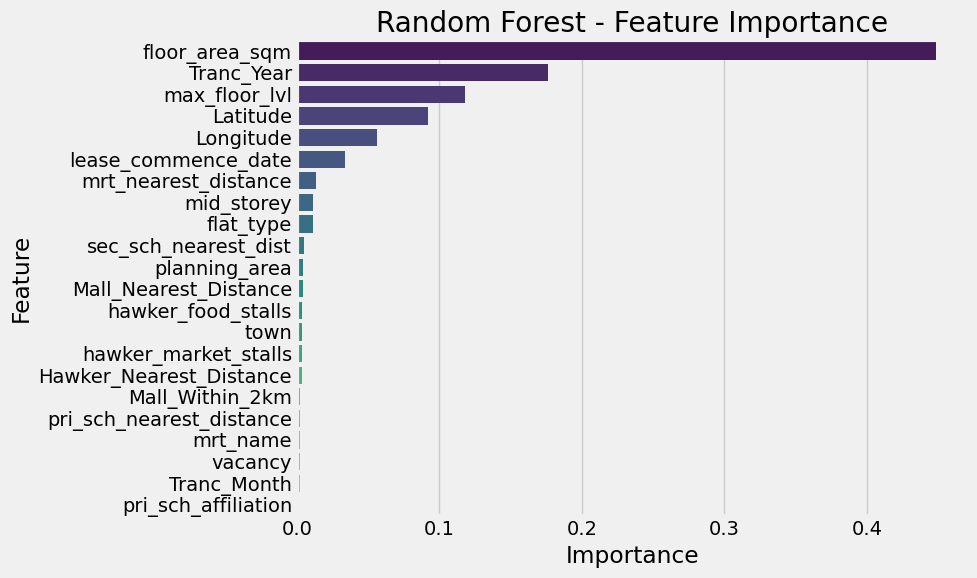

Feature Importance:
                 Feature  Importance
          floor_area_sqm    0.448609
              Tranc_Year    0.176019
           max_floor_lvl    0.117982
                Latitude    0.091827
               Longitude    0.056031
     lease_commence_date    0.033731
    mrt_nearest_distance    0.013050
              mid_storey    0.011354
               flat_type    0.011164
    sec_sch_nearest_dist    0.005023
           planning_area    0.004587
   Mall_Nearest_Distance    0.004482
      hawker_food_stalls    0.003909
                    town    0.003863
    hawker_market_stalls    0.003619
 Hawker_Nearest_Distance    0.003227
         Mall_Within_2km    0.002488
pri_sch_nearest_distance    0.002440
                mrt_name    0.002425
                 vacancy    0.002051
             Tranc_Month    0.001971
     pri_sch_affiliation    0.000150


In [40]:
# Feature importance for Random Forest
rf_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': rf_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(rf_importance.to_string(index=False))

---

## Step 11: Train and Evaluate LightGBM Model

In [41]:
# ========== LIGHTGBM ==========
# Hyperparameters (modify as needed)
lgbm_model = lgb.LGBMRegressor(
    n_estimators=100,          # Number of boosting rounds
    max_depth=15,              # Maximum depth of trees
    learning_rate=0.1,         # Learning rate
    num_leaves=31,             # Maximum number of leaves in one tree
    min_child_samples=20,      # Minimum samples in a leaf
    random_state=RANDOM_STATE,
    verbose=-1                 # Suppress output
)

# Train and evaluate
lgbm_results = evaluate_model(lgbm_model, X_train, X_test, y_train, y_test, 'LightGBM')
display_results(lgbm_results)

MODEL: LightGBM
Train R² Score: 0.9652
Test R² Score:  0.9637

Train RMSE: $32,719.93
Test RMSE:  $33,368.98



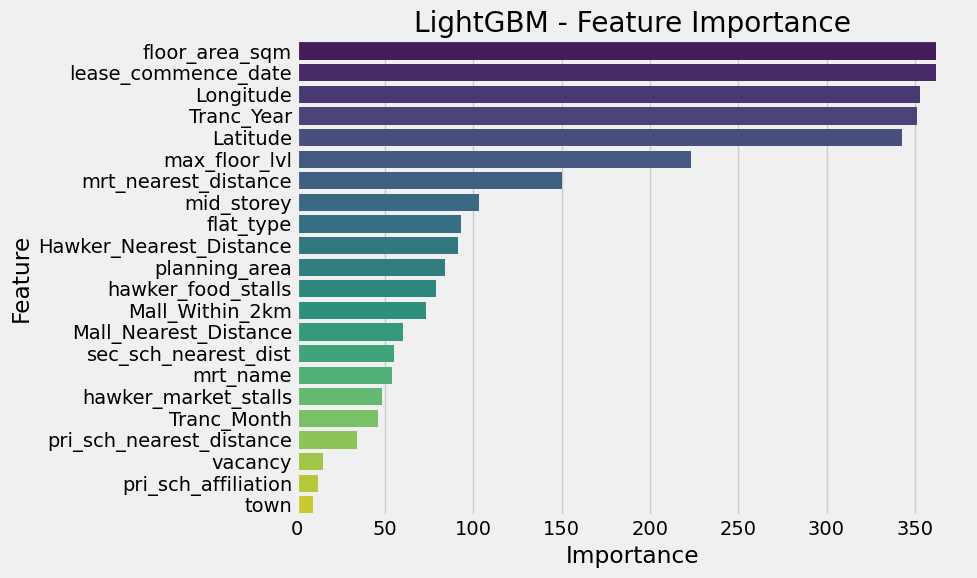

Feature Importance:
                 Feature  Importance
          floor_area_sqm         362
     lease_commence_date         362
               Longitude         353
              Tranc_Year         351
                Latitude         343
           max_floor_lvl         223
    mrt_nearest_distance         150
              mid_storey         103
               flat_type          93
 Hawker_Nearest_Distance          91
           planning_area          84
      hawker_food_stalls          79
         Mall_Within_2km          73
   Mall_Nearest_Distance          60
    sec_sch_nearest_dist          55
                mrt_name          54
    hawker_market_stalls          48
             Tranc_Month          46
pri_sch_nearest_distance          34
                 vacancy          15
     pri_sch_affiliation          12
                    town           9


In [42]:
# Feature importance for LightGBM
lgbm_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': lgbm_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=lgbm_importance, x='Importance', y='Feature', palette='viridis')
plt.title('LightGBM - Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(lgbm_importance.to_string(index=False))

---

## Step 12: Train and Evaluate XGBoost Model

In [43]:
# ========== XGBOOST ==========
# Hyperparameters (modify as needed)
xgb_model = xgb.XGBRegressor(
    n_estimators=100,          # Number of boosting rounds
    max_depth=10,              # Maximum depth of trees
    learning_rate=0.1,         # Learning rate
    min_child_weight=5,        # Minimum sum of instance weight in a child
    subsample=0.8,             # Subsample ratio of training instances
    colsample_bytree=0.8,      # Subsample ratio of columns
    random_state=RANDOM_STATE,
    verbosity=0                # Suppress output
)

# Train and evaluate
xgb_results = evaluate_model(xgb_model, X_train, X_test, y_train, y_test, 'XGBoost')
display_results(xgb_results)

MODEL: XGBoost
Train R² Score: 0.9853
Test R² Score:  0.9780

Train RMSE: $21,260.92
Test RMSE:  $25,933.01



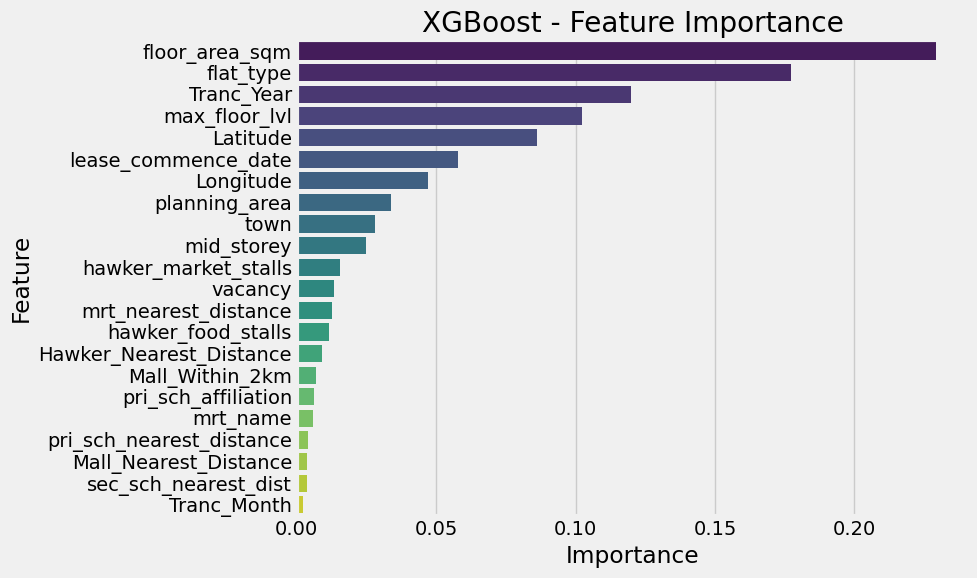

Feature Importance:
                 Feature  Importance
          floor_area_sqm    0.229334
               flat_type    0.177147
              Tranc_Year    0.119709
           max_floor_lvl    0.102274
                Latitude    0.086033
     lease_commence_date    0.057794
               Longitude    0.047129
           planning_area    0.033687
                    town    0.027977
              mid_storey    0.024724
    hawker_market_stalls    0.015382
                 vacancy    0.013322
    mrt_nearest_distance    0.012567
      hawker_food_stalls    0.011654
 Hawker_Nearest_Distance    0.009152
         Mall_Within_2km    0.006844
     pri_sch_affiliation    0.006118
                mrt_name    0.005874
pri_sch_nearest_distance    0.003840
   Mall_Nearest_Distance    0.003649
    sec_sch_nearest_dist    0.003515
             Tranc_Month    0.002275


In [44]:
# Feature importance for XGBoost
xgb_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': xgb_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_importance, x='Importance', y='Feature', palette='viridis')
plt.title('XGBoost - Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(xgb_importance.to_string(index=False))

---

## Step 13: Train and Evaluate CatBoost Model

In [45]:
# ========== CATBOOST ==========
# Hyperparameters (modify as needed)
catboost_model = CatBoostRegressor(
    iterations=100,            # Number of boosting iterations
    depth=10,                  # Depth of the tree
    learning_rate=0.1,         # Learning rate
    l2_leaf_reg=3,             # L2 regularization coefficient
    random_state=RANDOM_STATE,
    verbose=0                  # Suppress output
)

# Train and evaluate
catboost_results = evaluate_model(catboost_model, X_train, X_test, y_train, y_test, 'CatBoost')
display_results(catboost_results)

MODEL: CatBoost
Train R² Score: 0.9686
Test R² Score:  0.9671

Train RMSE: $31,048.32
Test RMSE:  $31,735.78



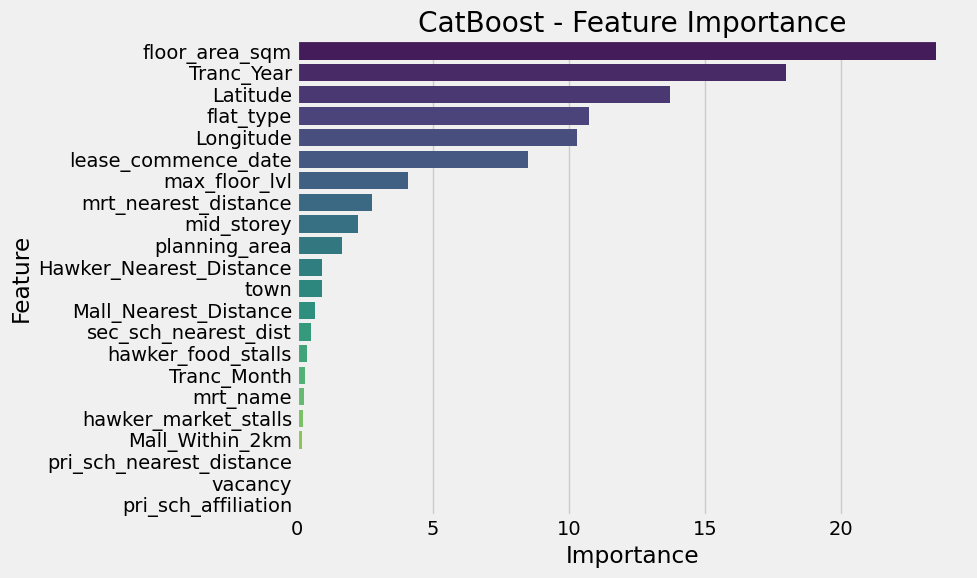

Feature Importance:
                 Feature  Importance
          floor_area_sqm   23.480233
              Tranc_Year   17.976131
                Latitude   13.715036
               flat_type   10.734001
               Longitude   10.294855
     lease_commence_date    8.500137
           max_floor_lvl    4.091765
    mrt_nearest_distance    2.769361
              mid_storey    2.248592
           planning_area    1.673888
 Hawker_Nearest_Distance    0.932039
                    town    0.916223
   Mall_Nearest_Distance    0.651017
    sec_sch_nearest_dist    0.506812
      hawker_food_stalls    0.377502
             Tranc_Month    0.294195
                mrt_name    0.277198
    hawker_market_stalls    0.214110
         Mall_Within_2km    0.177689
pri_sch_nearest_distance    0.094539
                 vacancy    0.039702
     pri_sch_affiliation    0.034976


In [46]:
# Feature importance for CatBoost
catboost_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': catboost_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=catboost_importance, x='Importance', y='Feature', palette='viridis')
plt.title('CatBoost - Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(catboost_importance.to_string(index=False))

---

## Step 14: Model Comparison Summary Table

Compare the performance of all five models side-by-side.

In [ ]:
# Collect results from all models (including Linear Regression baseline)
all_results = [lr_results, rf_results, lgbm_results, xgb_results, catboost_results]

# Create comparison DataFrame
comparison_df = pd.DataFrame([
    {
        'Model': r['Model'],
        'Train R²': round(r['Train R²'], 4),
        'Test R²': round(r['Test R²'], 4),
        'Train RMSE': round(r['Train RMSE'], 2),
        'Test RMSE': round(r['Test RMSE'], 2)
    }
    for r in all_results
])

# Sort by Test R² (best performance first)
comparison_df = comparison_df.sort_values('Test R²', ascending=False).reset_index(drop=True)

print("=" * 70)
print("MODEL COMPARISON SUMMARY (5 Models)")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 70)



MODEL COMPARISON SUMMARY (5 Models)
            Model  Train R²  Test R²  Train RMSE  Test RMSE
          XGBoost    0.9853   0.9780    21260.92   25933.01
         CatBoost    0.9686   0.9671    31048.32   31735.78
    Random Forest    0.9750   0.9638    27748.12   33293.88
         LightGBM    0.9652   0.9637    32719.93   33368.98
Linear Regression    0.8356   0.8368    71094.23   70705.68



In [51]:
# Save a CSV with a fixed model order (independent of cell 42 display sorting)
export_order = ['Linear Regression', 'Random Forest', 'LightGBM', 'XGBoost', 'CatBoost']

comparison_df_export = comparison_df.copy()
comparison_df_export['Model'] = pd.Categorical(
    comparison_df_export['Model'],
    categories=export_order,
    ordered=True
)
comparison_df_export = comparison_df_export.sort_values('Model').reset_index(drop=True)

comparison_df_export.to_csv('model_comparison_results.csv', index=False)
print("Saved model_comparison_results.csv with model order:")
print("Linear Regression -> Random Forest -> LightGBM -> XGBoost -> CatBoost")

Saved model_comparison_results.csv with model order:
Linear Regression -> Random Forest -> LightGBM -> XGBoost -> CatBoost


In [48]:
# Identify best model
best_model_idx = comparison_df['Test R²'].idxmax()
best_model = comparison_df.loc[best_model_idx]

print("\n" + "*" * 50)
print("BEST PERFORMING MODEL")
print("*" * 50)
print(f"Model: {best_model['Model']}")
print(f"Test R²: {best_model['Test R²']:.4f}")
print(f"Test RMSE: ${best_model['Test RMSE']:,.2f}")
print("*" * 50)


**************************************************
BEST PERFORMING MODEL
**************************************************
Model: XGBoost
Test R²: 0.9780
Test RMSE: $25,933.01
**************************************************


---

## Summary Checklist

- [ ] **Step 1:** Identified target variable (`resale_price`)
- [ ] **Step 2:** Imported packages and loaded data
- [ ] **Step 3:** Explored dataset structure
- [ ] **Step 3.5:** Feature engineering (optional)
- [ ] **Step 4:** Selected features for modeling
- [ ] **Step 5:** Analyzed feature correlations
- [ ] **Step 6:** Prepared data (handled missing values, encoded categoricals)
- [ ] **Step 7:** Split data into train/test sets
- [ ] **Step 8:** Defined model evaluation function
- [ ] **Step 9:** Trained Linear Regression model (Baseline)
- [ ] **Step 10:** Trained Random Forest model
- [ ] **Step 11:** Trained LightGBM model
- [ ] **Step 12:** Trained XGBoost model
- [ ] **Step 13:** Trained CatBoost model
- [ ] **Step 14:** Compared all 5 models (R² and RMSE)